# DSB Assignment — Part I, Questions 1–13
**Global Events, Commodities and Currency Markets** · *Group 8*

This notebook covers the first block of Part I:

| Block | Questions | Content |
|-------|-----------|---------|
| **A. Data Preparation & Understanding** | Q1–Q5 | date ranges, row counts, data-quality checks, date conversion, SWIFT metric list |
| **B. Descriptive Analytics** | Q6–Q12 | highest/lowest prices & years, annual averages, top-5 average years |
| **C. Trend & Visual Analytics** | Q13 | Brent Oil line chart + interpretation |

**Reproducibility:** all data loading, cleaning, styling and IO go through the shared
module `src/dsb_utils.py`, using **relative paths only** — *Restart & Run All* reproduces
every table and figure on any machine. Tables are written to `01-13Q/tables/` (CSV) and
charts to `01-13Q/figures/` (PNG).

In [1]:
# --- Bootstrap: put the shared module on the path (works from any working dir) ---
import os, sys
_d = os.getcwd()
while _d != os.path.dirname(_d) and not os.path.exists(os.path.join(_d, "src", "dsb_utils.py")):
    _d = os.path.dirname(_d)
sys.path.insert(0, os.path.join(_d, "src"))

import pandas as pd
import matplotlib.pyplot as plt
import dsb_utils as dsb

dsb.apply_style()                      # one uniform chart style across all notebooks
QDIR = os.path.join(dsb.ROOT, "part1")  # where this notebook's figures/ & tables/ live

# Load everything through the robust loaders (Brent uses '-', Gold/Silver use '/')
commodities = dsb.load_all_commodities()
brent, gold, silver = commodities["Brent Oil"], commodities["Gold"], commodities["Silver"]
swift = dsb.load_swift()

print("Loaded:", {n: d.shape for n, d in commodities.items()}, "| SWIFT:", swift.shape)

Loaded: {'Brent Oil': (963, 4), 'Gold': (1336, 4), 'Silver': (1336, 4)} | SWIFT: (330, 10)


---
## A. Data Preparation & Understanding (Q1–Q5)

### Q1 & Q2 — Date range and row count for each dataset

In [2]:
def _swift_data_months(s):
    dm = pd.to_datetime(s["data_month"], format="%B %Y", errors="coerce")
    return dm.min(), dm.max()

sw_start, sw_end = _swift_data_months(swift)

overview_rows = []
for n, d in commodities.items():
    overview_rows.append({
        "Dataset": n, "Rows": len(d), "Columns": d.shape[1] - 2,  # exclude derived Year/Month
        "Start": d["Date"].min().strftime("%b %Y"),
        "End": d["Date"].max().strftime("%b %Y"),
        "Frequency": "Monthly",
    })
overview_rows.append({
    "Dataset": "SWIFT Currency Tracker", "Rows": len(swift), "Columns": swift.shape[1],
    "Start": sw_start.strftime("%b %Y"), "End": sw_end.strftime("%b %Y"),
    "Frequency": "4 monthly reports",
})
overview = pd.DataFrame(overview_rows)
dsb.save_table(overview, "Q01-02_dataset_overview", QDIR)
overview

saved table  -> part1/tables/Q01-02_dataset_overview.csv


,Dataset,Rows,Columns,Start,End,Frequency
0,Brent Oil,963,2,Jan 1946,Mar 2026,Monthly
1,Gold,1336,2,Jan 1915,Apr 2026,Monthly
2,Silver,1336,2,Jan 1915,Apr 2026,Monthly
3,SWIFT Currency Tracker,330,10,Dec 2025,Mar 2026,4 monthly reports


### Q3 — Missing values and repeated dates

In [3]:
dq_rows = []
for n, d in commodities.items():
    dq_rows.append({
        "Dataset": n,
        "Missing Value": int(d["Value"].isna().sum()),
        "Missing Date": int(d["Date"].isna().sum()),
        "Duplicate dates": int(d["Date"].duplicated().sum()),
        "Duplicate rows": int(d.duplicated().sum()),
    })
dq_rows.append({
    "Dataset": "SWIFT Currency Tracker",
    "Missing Value": int(swift["value"].isna().sum()),
    "Missing Date": int(swift["data_month"].isna().sum()),
    "Duplicate dates": "n/a (panel)",
    "Duplicate rows": int(swift.duplicated().sum()),
})
data_quality = pd.DataFrame(dq_rows)
dsb.save_table(data_quality, "Q03_data_quality", QDIR)
data_quality

saved table  -> part1/tables/Q03_data_quality.csv


,Dataset,Missing Value,Missing Date,Duplicate dates,Duplicate rows
0,Brent Oil,0,0,0,0
1,Gold,0,0,0,0
2,Silver,0,0,0,0
3,SWIFT Currency Tracker,42,0,n/a (panel),0


### Q4 — Convert Date to a proper date type; add Month and Year

In [4]:
print("dtypes after conversion:")
print(brent.dtypes, "\n")
print("Brent with derived Year/Month (first & last 3 rows):")
display(pd.concat([brent.head(3), brent.tail(3)])[["Date", "Value", "Year", "Month"]])

dtypes after conversion:
Date     datetime64[ns]
Value           float64
Year              int32
Month             int32
dtype: object 

Brent with derived Year/Month (first & last 3 rows):


,Date,Value,Year,Month
0,1946-01-01,21.23,1946,1
1,1946-02-01,21.35,1946,2
2,1946-03-01,21.11,1946,3
960,2026-01-01,65.48,2026,1
961,2026-02-01,67.66,2026,2
962,2026-03-01,102.86,2026,3


**Cleaning note.** Each `Date` string is parsed to a true `datetime64[ns]` using an explicit
month-first format (`%m/%d/%Y` after normalising `-`→`/`), which avoids pandas mis-reading the
fixed `01` day component as a month. `Value` is coerced to numeric, rows are sorted
chronologically and re-indexed, and `Year`/`Month` integer columns are added to support the
annual aggregations used throughout Part I. The same routine (`dsb.load_commodity`) is reused
by every notebook so the cleaning is identical everywhere.

### Q5 — Main metrics available in the SWIFT dataset

In [5]:
metric_summary = (
    swift.groupby(["metric", "category"])
    .agg(Rows=("value", "size"),
         Reports=("report_month", "nunique"))
    .reset_index()
    .sort_values("Rows", ascending=False)
    .reset_index(drop=True)
)
dsb.save_table(metric_summary, "Q05_swift_metrics", QDIR)
metric_summary

saved table  -> part1/tables/Q05_swift_metrics.csv


,metric,category,Rows,Reports
0,Global Payment Share,Currency Ranking,80,4
1,International Payment Share (ex-Eurozone),Currency Ranking,80,4
2,Offshore RMB by Economy,Offshore Economies,60,4
3,FX Spot Currency Ranking,FX Spot,40,4
4,Trade Finance Share,Currency Ranking,40,4
5,FX Spot Economies (RMB),Offshore Economies,24,4
6,RMB MoM Payment Growth,RMB Activity,4,4
7,All Currencies MoM Payment Growth,Market Activity,2,2


---
## B. Descriptive Analytics (Q6–Q12)

### Q6–Q8 — Highest and lowest prices, and the years they occurred

In [6]:
def extremes(name, d):
    hi, lo = d.loc[d["Value"].idxmax()], d.loc[d["Value"].idxmin()]
    return {
        "Commodity": name,
        "Highest price (USD)": round(hi["Value"], 2), "Highest month": hi["Date"].strftime("%b %Y"),
        "Highest year": int(hi["Year"]),
        "Lowest price (USD)": round(lo["Value"], 2), "Lowest month": lo["Date"].strftime("%b %Y"),
        "Lowest year": int(lo["Year"]),
    }

price_extremes = pd.DataFrame([extremes(n, d) for n, d in commodities.items()])
dsb.save_table(price_extremes, "Q06-08_price_extremes", QDIR)
price_extremes

saved table  -> part1/tables/Q06-08_price_extremes.csv


,Commodity,Highest price (USD),Highest month,Highest year,Lowest price (USD),Lowest month,Lowest year
0,Brent Oil,211.21,Jun 2008,2008,21.11,Mar 1946,1946
1,Gold,5277.89,Feb 2026,2026,19.25,Jan 1915,1915
2,Silver,113.95,Jan 2026,2026,0.28,Jan 1932,1932


### Q9 — Average price by year for Brent Oil, Gold and Silver

In [7]:
annual_avg = pd.concat(
    [brent.groupby("Year")["Value"].mean().rename("Brent Oil"),
     gold.groupby("Year")["Value"].mean().rename("Gold"),
     silver.groupby("Year")["Value"].mean().rename("Silver")],
    axis=1,
).round(2)
dsb.save_table(annual_avg, "Q09_annual_average", QDIR, index=True)
print(f"Annual-average table: {annual_avg.shape[0]} years ({annual_avg.index.min()}–{annual_avg.index.max()})")
display(pd.concat([annual_avg.head(4), annual_avg.tail(6)]))

saved table  -> part1/tables/Q09_annual_average.csv
Annual-average table: 112 years (1915–2026)


,Brent Oil,Gold,Silver
Year,,,
1946,22.90,35.00,0.80
1947,27.20,35.00,0.72
1948,35.31,35.00,0.74
1949,35.65,31.88,0.72
1940,NaN,34.06,0.35
1941,NaN,34.06,0.35
1942,NaN,34.06,0.38
1943,NaN,34.06,0.45
1944,NaN,34.06,0.45


### Q10 — Five years with the highest average Brent Oil price

In [8]:
top5_brent = (annual_avg["Brent Oil"].dropna().sort_values(ascending=False).head(5)
              .round(2).rename("Avg Brent (USD)").reset_index())
dsb.save_table(top5_brent, "Q10_top5_brent_years", QDIR)
top5_brent

saved table  -> part1/tables/Q10_top5_brent_years.csv


,Year,Avg Brent (USD)
0,2008,150.96
1,1980,149.86
2,2011,142.12
3,2013,138.30
4,2012,135.27


### Q11 — Five years with the highest average Gold price

In [9]:
top5_gold = (annual_avg["Gold"].dropna().sort_values(ascending=False).head(5)
             .round(2).rename("Avg Gold (USD)").reset_index())
dsb.save_table(top5_gold, "Q11_top5_gold_years", QDIR)
top5_gold

saved table  -> part1/tables/Q11_top5_gold_years.csv


,Year,Avg Gold (USD)
0,2026,4881.62
1,2025,3472.54
2,2024,2404.58
3,2023,1953.69
4,2022,1798.96


### Q12 — Five years with the highest average Silver price

In [10]:
top5_silver = (annual_avg["Silver"].dropna().sort_values(ascending=False).head(5)
               .round(2).rename("Avg Silver (USD)").reset_index())
dsb.save_table(top5_silver, "Q12_top5_silver_years", QDIR)
top5_silver

saved table  -> part1/tables/Q12_top5_silver_years.csv


,Year,Avg Silver (USD)
0,2026,96.08
1,2025,41.50
2,2011,35.56
3,2012,31.63
4,2024,28.13


---
## C. Trend & Visual Analytics (Q13)

### Q13 — Brent Oil price over time (line chart)

saved figure -> part1/figures/Q13_brent_trend.png


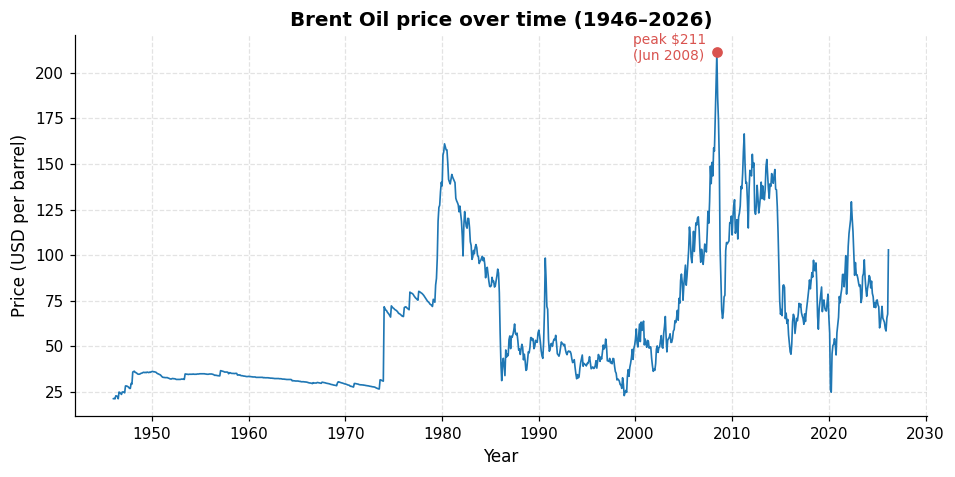

start (1946) ≈ $21.23 | peak $211.21 (Jun 2008)
COVID trough 2020 avg ≈ $49.19 | latest Mar 2026 = $102.86


In [11]:
fig, ax = plt.subplots()
ax.plot(brent["Date"], brent["Value"], color=dsb.COLORS["oil"], linewidth=1.1)

# annotate the all-time high so the reader can anchor the peak
peak = brent.loc[brent["Value"].idxmax()]
ax.scatter(peak["Date"], peak["Value"], color=dsb.COLORS["cny"], zorder=5)
ax.annotate(f"peak ${peak['Value']:.0f}\n({peak['Date'].strftime('%b %Y')})",
            (peak["Date"], peak["Value"]), textcoords="offset points", xytext=(-55, -5),
            fontsize=9, color=dsb.COLORS["cny"])

ax.set_title("Brent Oil price over time (1946–2026)")
ax.set_xlabel("Year"); ax.set_ylabel("Price (USD per barrel)")
dsb.save_fig(fig, "Q13_brent_trend", QDIR)
plt.show()

# key numbers referenced in the interpretation, computed (not typed)
ba = brent.groupby("Year")["Value"].mean()
print(f"start (1946) ≈ ${brent['Value'].iloc[0]:.2f} | peak ${peak['Value']:.2f} ({peak['Date'].strftime('%b %Y')})")
print(f"COVID trough 2020 avg ≈ ${ba.loc[2020]:.2f} | latest {brent['Date'].max():%b %Y} = ${brent['Value'].iloc[-1]:.2f}")

**Interpretation.** Brent starts around \$21/barrel in 1946 and stays fairly flat for decades before the 1970s oil shocks push it up sharply. From there it climbs, with ups and downs, into an all-time high of \$211.21 in June 2008, then crashes hard later that year. It recovers through the early 2010s, dips again in 2014-16, and falls to a 2020 average of \$49.19 during COVID. The most recent point in the data jumps from \$67.66 (Feb 2026) to \$102.86 (Mar 2026), a sudden one-month spike. The overall shape is less a steady trend and more long calm stretches broken by sharp shocks in both directions.

---
### Exported artifacts
All tables above are in `01-13Q/tables/` and the Brent chart in `01-13Q/figures/`.
These feed the consolidated `DSB_Group8_Workbook.xlsx` and are cited by Part II.

In [12]:
import os
print("tables/:", sorted(os.listdir(os.path.join(QDIR, "tables"))))
print("figures/:", sorted(os.listdir(os.path.join(QDIR, "figures"))))

tables/: ['B1_annual_pct_change.csv', 'B2_correlation.csv', 'DataQuality.csv', 'Q01-02_dataset_overview.csv', 'Q03_data_quality.csv', 'Q05_swift_metrics.csv', 'Q06-08_price_extremes.csv', 'Q09_annual_average.csv', 'Q10_top5_brent_years.csv', 'Q11_top5_gold_years.csv', 'Q12_top5_silver_years.csv', 'Q14-26_tables.xlsx', 'Q17_brent_last10.csv', 'Q18_latest_values.csv', 'Q19_top_currencies.csv', 'Q22_top5_frequency.csv', 'Q23_offshore_rmb.csv', 'Q27_volatility.csv', 'Q28_crisis_2020.csv', 'Q_summary.csv', 'annual_summary.csv', 'commodity_master.csv', 'swift_clean.csv']
figures/: ['Q13_brent_trend.png', 'Q14_gold_trend.png', 'Q15_silver_trend.png', 'Q16_gold_vs_silver.png', 'Q17_brent_last10.png', 'Q24_top10_currencies.png', 'b1_annual_pct_change.png', 'b3_correlation_heatmap.png', 'b4_gold_silver_scatter.png', 'b5_gold_moving_average.png', 'b6_gold_trendline_forecast.png', 'q27_normalised_index.png', 'q27_volatility_comparison.png', 'q28_crisis_2020.png', 'q29_dashboard.png']
